# Genome summary

This notebook contains some miscellaneous code to summarise various aspects of the genome assembly. 

## Repeat content per scaffold

I will quantify the percentage of each scaffold that was annotated as repetitive via our EDTA + repeatmasker pipeline. 

In [24]:
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
scaff_repeat_dict = {}
with open("/Users/dj20y461/Downloads/Gw.AX_Y.fasta.out") as RMout:

    header1 = next(RMout)
    header2 = next(RMout)
    header3 = next(RMout)

    for line in RMout:
        scaff = line.split()[4]
        length = max([int(line.split()[5]), int(line.split()[6])]) - min([int(line.split()[5]), int(line.split()[6])]) 

        if scaff not in scaff_repeat_dict:
            scaff_repeat_dict[scaff] = 0
        scaff_repeat_dict[scaff] += length

        

In [3]:
## get scaffold lengths from the genome index file

with open("/Users/dj20y461/Downloads/Gw.AX_Y.fasta.fai") as fai:
    scaff_length_dict = {}
    for line in fai:
        scaff = line.split()[0]
        length = int(line.split()[1])
        scaff_length_dict[scaff] = length


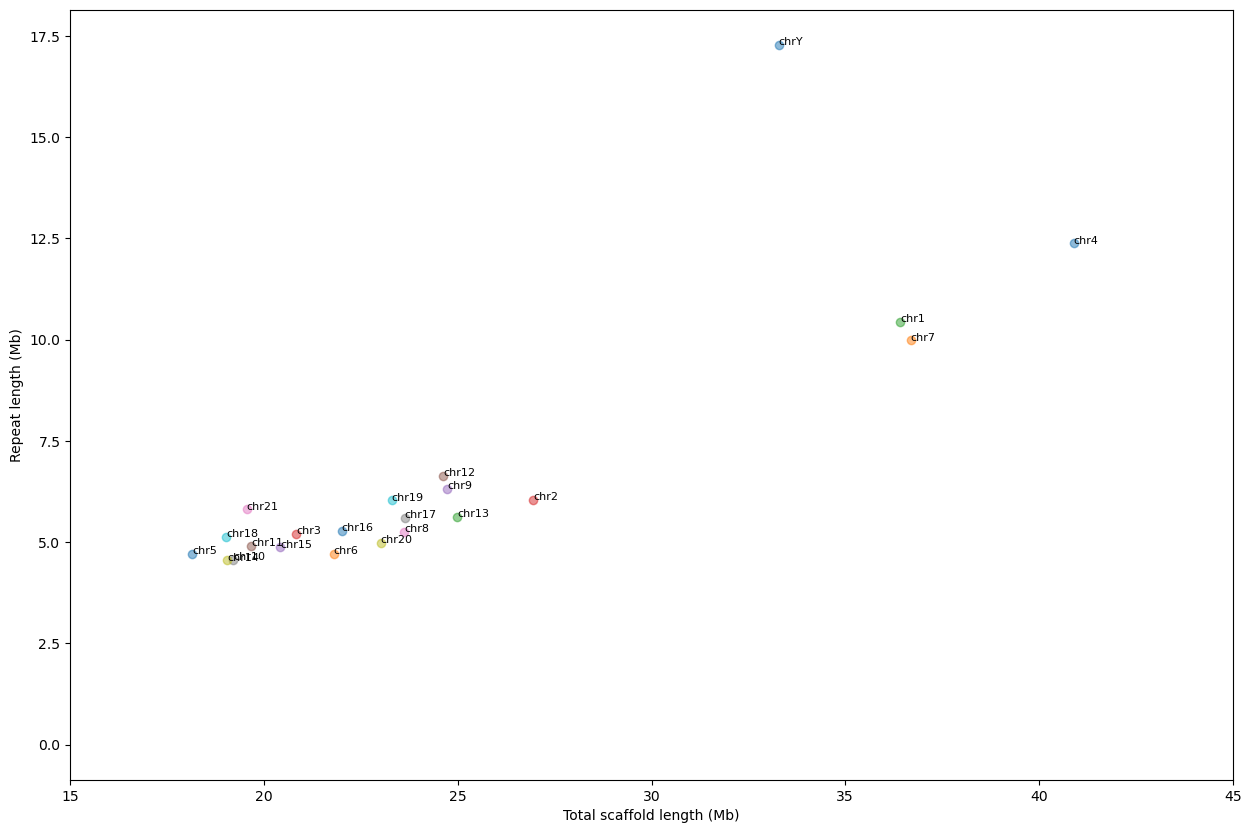

In [ ]:
fig = plt.figure(figsize=(15,10))

scaff_repeat_dict = {}

for scaff in scaff_length_dict:
    if scaff in scaff_repeat_dict:
        repeat_length = scaff_repeat_dict[scaff]
    else:
        repeat_length = 0
    total_length = scaff_length_dict[scaff]
    proportion = repeat_length / total_length
    scaff_repeat_proportion[scaff] = proportion

    plt.scatter(total_length/1000000, repeat_length/1000000, alpha = 0.5)
    
    if "chr" in scaff:
        plt.text(total_length/1000000, repeat_length/1000000, scaff, fontsize=8)

plt.ylabel("Repeat length (Mb)")
plt.xlabel("Total scaffold length (Mb)")
plt.xlim(15, 45)
plt.show()

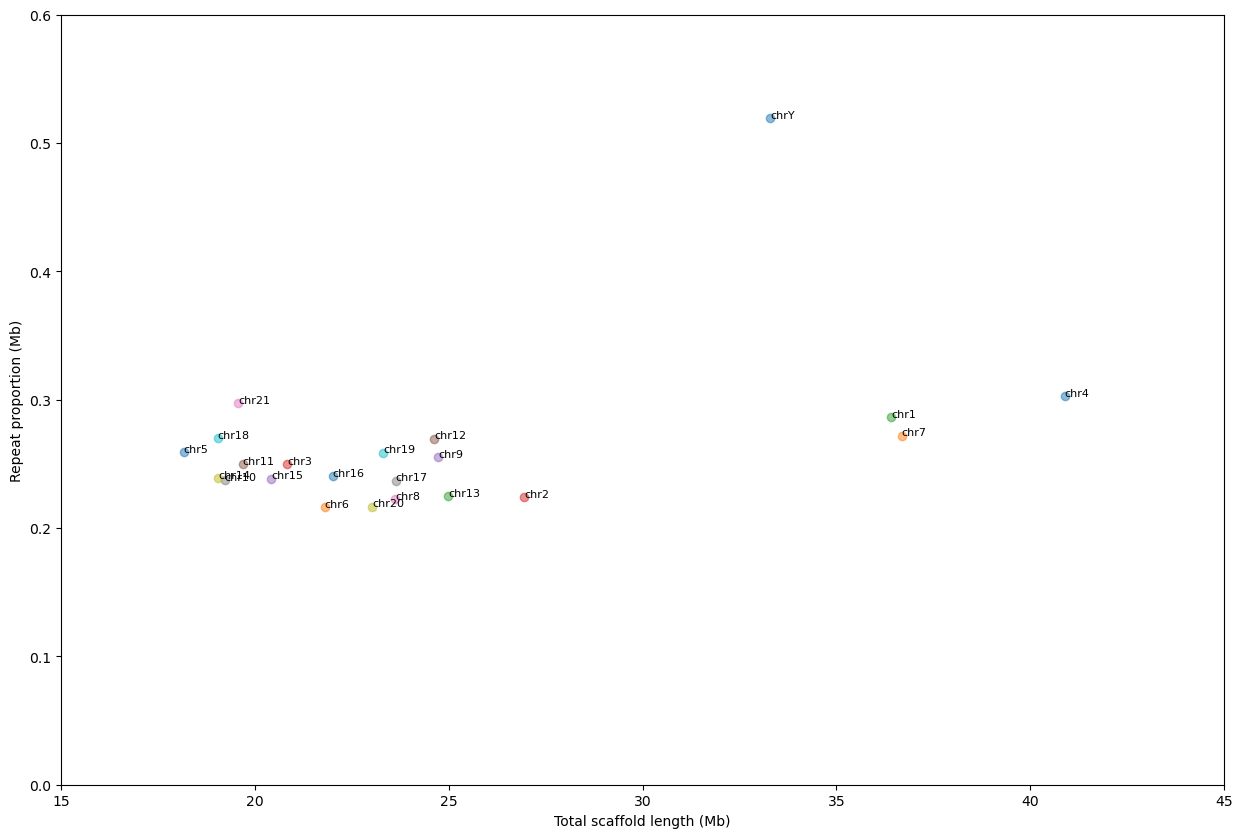

In [ ]:
fig = plt.figure(figsize=(15,10))

scaff_repeat_proportion = {}

for scaff in scaff_length_dict:
    if scaff in scaff_repeat_dict:
        repeat_length = scaff_repeat_dict[scaff]
    else:
        repeat_length = 0
    total_length = scaff_length_dict[scaff]
    proportion = repeat_length / total_length
    scaff_repeat_proportion[scaff] = proportion

    plt.scatter(total_length/1000000, proportion, alpha = 0.5)
    
    if "chr" in scaff:
        plt.text(total_length/1000000, proportion, scaff, fontsize=8)

plt.ylabel("Repeat proportion (Mb)")
plt.xlabel("Total scaffold length (Mb)")
plt.xlim(15, 45)
plt.ylim(0, 0.)
plt.show()

In [27]:
Auto_chr_proportions = []
Auto_scaff_proportions = []

Y_scaff_proportions = []

for scaff in scaff_repeat_proportion:
    if "chr" in scaff and scaff != "chrY":
        #print(scaff, scaff_repeat_proportion[scaff])

        Auto_chr_proportions.append(scaff_repeat_proportion[scaff])

    elif "Ascaf" in scaff: 
        Auto_scaff_proportions.append(scaff_repeat_proportion[scaff])

    elif "Yscaf" in scaff:
        Y_scaff_proportions.append(scaff_repeat_proportion[scaff])

print("Mean proportion across autosomes:", np.mean(Auto_chr_proportions))
print("Mean proportion across autosomal scaffolds:", np.mean(Auto_scaff_proportions))

print("Proportion of Y chromosome:", np.mean(scaff_repeat_proportion["chrY"]))
print("Mean proportion across Y scaffs:", np.mean(Y_scaff_proportions))
        


Mean proportion across autosomes: 0.2508483764919763
Mean proportion across autosomal scaffolds: 0.6575473268530018
Proportion of Y chromosome: 0.519245111548449
Mean proportion across Y scaffs: 0.7495302765893529


I'd like to now do the above but split the Y into its chr12 and chr19 parts. 

In [29]:
## Y_19 regions

Y_12_regions = [(0, 16.12),
                (19.85, 22.91)]

Y_19_regions = [(16.5, 19.85),
                (23, 32)]

How long are the two regions?

In [30]:
Y_12_len = Y_12_regions[0][1] - Y_12_regions[0][0] + Y_12_regions[1][1] - Y_12_regions[1][0]
print("Y_12 is %s Mb long" % Y_12_len)

Y_19_len = Y_19_regions[0][1] - Y_19_regions[0][0] + Y_19_regions[1][1] - Y_19_regions[1][0]
print("Y_19 is %s Mb long" % Y_19_len)

Y_12 is 19.18 Mb long
Y_19 is 12.350000000000001 Mb long


How many genes are there in each of the two regions? 

In [49]:
gene_dict = {}

Y12_genes = []
Y19_genes = []

with open("/Users/dj20y461/Downloads/Gw.braker.annotation.gff") as gff:

    for line in gff:

        if line.split()[2] == "gene":
            chrom = line.split()[0]
            pos = int(line.split()[3])
            geneid = line.split()[8].split(";")[0].replace("ID=","")

            if chrom == "chrY":
                for region in Y_12_regions:
                    if pos/1000000 >= region[0] and pos/1000000 <= region[1]:
                        Y12_genes.append(geneid)
                                  
                for region in Y_19_regions:
                    if pos/1000000 >= region[0] and pos/1000000 <= region[1]:
                        Y19_genes.append(geneid)

In [51]:
print("%s genes found in the Y12 region" % len(Y12_genes))
print("%s genes found in the Y19 region" % len(Y19_genes))

786 genes found in the Y12 region
161 genes found in the Y19 region


How many repeats are there in the two regions? 

In [61]:
scaff_repeat_pos_dict = {}
with open("/Users/dj20y461/Downloads/Gw.AX_Y.fasta.out") as RMout:

    header1 = next(RMout)
    header2 = next(RMout)
    header3 = next(RMout)

    for line in RMout:
        scaff = line.split()[4]
        pos = min([int(line.split()[5]), int(line.split()[6])])
        length = max([int(line.split()[5]), int(line.split()[6])]) - min([int(line.split()[5]), int(line.split()[6])])

        if scaff not in scaff_repeat_pos_dict:
            scaff_repeat_pos_dict[scaff] = {}
        scaff_repeat_pos_dict[scaff][pos] = length

        

In [62]:
scaff_repeat_pos_dict

{'Ascaf_100': {1: 99,
  68: 39,
  2732: 20,
  5949: 118,
  6056: 74,
  6138: 967,
  7115: 671,
  7857: 414,
  8218: 177,
  8396: 538,
  9126: 2086,
  11273: 60,
  11453: 47,
  14019: 19,
  17199: 963,
  18172: 672,
  18915: 359,
  19267: 276,
  19544: 67,
  19558: 166,
  19725: 521,
  20356: 126,
  20483: 2245,
  22789: 60,
  22969: 47,
  28664: 120,
  28773: 74,
  28855: 962,
  29827: 672,
  30484: 83,
  30568: 359,
  30920: 277,
  31198: 67,
  31212: 177,
  31390: 520,
  32104: 21},
 'Ascaf_101': {1: 192,
  338: 22,
  665: 32,
  995: 223,
  1219: 37,
  1257: 162,
  1420: 63,
  3354: 283,
  3710: 94,
  5560: 48,
  6873: 17,
  7197: 68,
  7403: 254,
  8512: 35,
  8768: 103,
  8875: 378,
  9667: 729,
  10477: 212,
  10639: 101,
  10692: 61,
  10757: 647,
  11404: 89,
  11634: 54,
  11723: 145,
  11950: 212,
  12112: 101,
  12165: 61,
  12230: 647,
  12877: 89,
  13107: 74,
  13381: 26,
  13858: 637,
  15135: 36,
  15595: 19,
  17615: 67,
  17677: 54,
  17732: 26,
  19888: 56,
  19945: 3

In [63]:
Y12_repeats = 0
Y19_repeats = 0

for scaff in scaff_repeat_pos_dict:
    if scaff == "chrY":
        for pos in scaff_repeat_pos_dict[scaff]:
            for region in Y_12_regions:
                if pos/1000000 >= region[0] and pos/1000000 <= region[1]:
                    Y12_repeats += scaff_repeat_pos_dict[scaff][pos]
                                  
            for region in Y_19_regions:
                if pos/1000000 >= region[0] and pos/1000000 <= region[1]:
                    Y19_repeats += scaff_repeat_pos_dict[scaff][pos]

In [69]:
Y12_repeats_Mb = np.round((Y12_repeats/1000000), 2)
Y19_repeats_Mb = np.round((Y19_repeats/1000000), 2)

prop_Y12_repeats = np.round((Y12_repeats_Mb/Y_12_len)*100, 2)
prop_Y19_repeats = np.round((Y19_repeats_Mb/Y_19_len)*100, 2)

print("Length Y12 = %s Mb" % Y_12_len)
print("Sum repeat content Y12 = %s Mb" % Y12_repeats_Mb)
print("Repetitive proportion of Y12 = %s%%" % prop_Y12_repeats)

print("Length Y19 = %s Mb" % Y_19_len)
print("Sum repeat content Y19 = %s Mb" % Y19_repeats_Mb)
print("Repetitive proportion of Y19 = %s%%" % prop_Y19_repeats)



Length Y12 = 19.18 Mb
Sum repeat content Y12 = 6.1 Mb
Repetitive proportion of Y12 = 31.8%
Length Y19 = 12.350000000000001 Mb
Sum repeat content Y19 = 9.79 Mb
Repetitive proportion of Y19 = 79.27%
